## TrainSet 과 TestSet 으로 나누어 사용하기

#### Train Set 과 Test Set 의 필요성
- 모든 문제와 답을 알려주고 해당 범위내에서 점수를 내면 항상 100점
- 한 개의 Data Set 을 Train 부분과 Test 부분으로 분리
- Train Set 은 학습하고 학습한 결과 내용으로 Test Set 으로 검증하여야 모델의 정확성 신뢰

In [1]:
import pandas as pd

In [4]:
fruits = pd.read_csv('../Data/fruits.csv')
fruits.head()

,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Train Set 과 Test Set 분리

In [36]:
# Train Set
train_input = fruits.loc[:35, ['length', 'weight']]
train_input.tail()

,length,weight
31,38.5,955.0
32,39.5,925.0
33,41.0,975.0
34,41.0,950.0
35,9.8,6.7


In [19]:
train_target = fruits.loc[:35, 'name']
train_target.tail()

31    apple
32    apple
33    apple
34    apple
35    berry
Name: name, dtype: object

In [34]:
# Test Set
test_input = fruits.loc[35:, ['length', 'weight']]
test_input.head()

,length,weight
35,9.8,6.7
36,10.5,7.5
37,10.6,7.0
38,11.0,9.7
39,11.2,9.8


In [29]:
# Test Set
test_target = fruits.loc[35:, 'name']
test_target.tail()

44    berry
45    berry
46    berry
47    berry
48    berry
Name: name, dtype: object

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [30]:
# Model
kn = KNeighborsClassifier()

In [31]:
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

0.9722222222222222
0.0


---
#### Numpy를 이용하여 샘플링 편향 제거

In [37]:
import numpy as np

In [40]:
np.random.seed(42) # random sample을 하나로 정의하여 다른 모델에서도 동일한 값으로 예측 수행
index = np.arange(49)
np.random.shuffle(index)
print(index)

[13 45 47 44 17 27 26 25 31 19 12  4 34  8  3  6 40 41 46 15  9 16 24 33
 30  0 43 32  5 29 11 36  1 21  2 37 35 23 39 10 22 18 48 20  7 42 14 28
 38]


In [41]:
# train data 구성
train_input = fruits.loc[index[:35], ['length', 'weight']]
train_input.head()

,length,weight
13,32.0,340.0
45,12.4,13.4
47,14.3,19.7
44,12.2,12.2
17,33.0,700.0


In [42]:
train_target = fruits.loc[index[:35], 'name']
train_target.head()

13    apple
45    berry
47    berry
44    berry
17    apple
Name: name, dtype: object

In [43]:
# test data 구성
test_input = fruits.loc[index[35:], ['length', 'weight']]
test_input.head()

,length,weight
37,10.6,7.0
35,9.8,6.7
23,35.0,680.0
39,11.2,9.8
10,31.0,475.0


In [45]:
test_target = fruits.loc[index[35:], 'name']
test_target.head()

37    berry
35    berry
23    apple
39    berry
10    apple
Name: name, dtype: object

### Data 의 분포를 산포도로 확인

In [46]:
import matplotlib.pyplot as plt

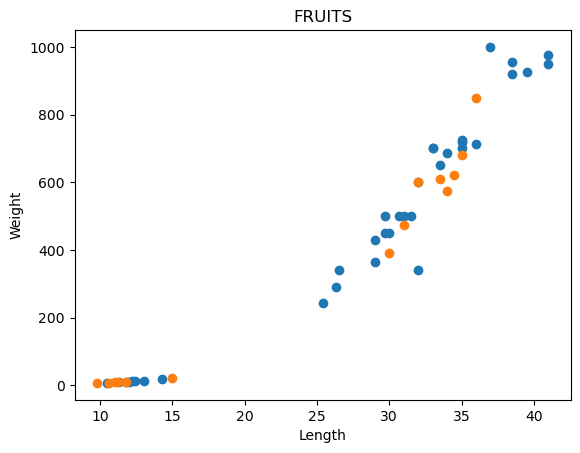

In [48]:
# 산포도로 예측범위 확인

plt.scatter(
    train_input['length'],
    train_input['weight']
)

# berry 산포도
plt.scatter(
    test_input['length'],
    test_input['weight']
)

plt.xlabel('Length')
plt.ylabel('Weight')
plt.title('FRUITS')

plt.show()
# Python 에서는 한 셀에 plt 2개 있으면 색으로 구분하여 한 번에 표시

In [ ]:
# knn으로 훈련
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [50]:
# 정확도 출력
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0


---
#### sklearn 으로 Train Set 과 Test Set 나누기

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
# Feature 와 Target 으로 분리
fruits_data = fruits[['length', 'weight']]
fruits_data.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


In [54]:
fruits_target = fruits['name']
fruits_target.head()

0    apple
1    apple
2    apple
3    apple
4    apple
Name: name, dtype: object

In [55]:
train_input, test_input, train_target, test_target = \
train_test_split(
    fruits_data,
    fruits_target,
    random_state = 42
)

In [58]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(36, 2) (36,)
(13, 2) (13,)


### 빈도수 확인

In [59]:
import collections

In [60]:
# fruits 의 성격
collections.Counter(fruits['name'])

Counter({'apple': 35, 'berry': 14})

In [61]:
35 / 14

2.5

In [62]:
# train 으 빈도수
collections.Counter(train_target)

Counter({'apple': 25, 'berry': 11})

In [63]:
25 / 11

2.272727272727273

In [64]:
# test 의 빈도수
collections.Counter(test_target)

Counter({'apple': 10, 'berry': 3})

In [65]:
10 / 3

3.3333333333333335

> apple 과 berry 의 비율을 비슷하게 할 필요가 있다 = Sampling 의 기본

In [70]:
train_input, test_input, train_target, test_target = \
train_test_split(
    fruits_data,
    fruits_target,
    random_state = 42,
    stratify=fruits_target # target의 비율 검토
)

In [71]:
collections.Counter(test_target)

Counter({'apple': 9, 'berry': 4})

In [72]:
collections.Counter(train_target)

Counter({'apple': 26, 'berry': 10})

In [73]:
kn.fit(train_input, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [74]:
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0
